# Імпорти та налаштування

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# Константа для відтворюваності результатів
RANDOM_STATE = 42

# Налаштування графіків
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")

# Шлях для збереження графіків
FIGURES_DIR = "figures"

print("Імпорти завершено успішно.")

Імпорти завершено успішно.


# Завантаження та первинний аналіз даних

In [2]:
# Завантаження датасету
data = load_breast_cancer()

# Перетворення у DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

# Назви класів
target_names = data.target_names  # ['malignant', 'benign']
print(f"Класи: {target_names}")
print(f"Кількість об'єктів: {df.shape[0]}")
print(f"Кількість ознак: {df.shape[1] - 1}")
print(f"Кількість класів: {len(target_names)}")

Класи: ['malignant' 'benign']
Кількість об'єктів: 569
Кількість ознак: 30
Кількість класів: 2


In [3]:
# Перші 5 рядків
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# Статистичний опис ознак
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [5]:
# Інформація про типи даних та пропущені значення
print("Інформація про датасет:")
df.info()
print(f"\nПропущені значення:\n{df.isnull().sum().sum()} (загалом)")

Інформація про датасет:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness er

Розподіл класів:
  benign (1): 357 (62.7%)
  malignant (0): 212 (37.3%)


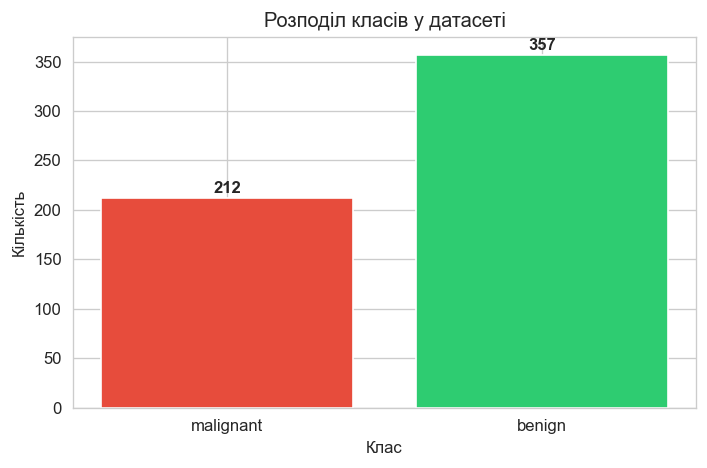

In [6]:
# Розподіл класів
class_counts = df["target"].value_counts()
print("Розподіл класів:")
for idx, count in class_counts.items():
    print(f"  {target_names[idx]} ({idx}): {count} ({count / len(df) * 100:.1f}%)")

# Візуалізація розподілу класів
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(target_names, class_counts.sort_index().values, color=["#e74c3c", "#2ecc71"])
ax.set_title("Розподіл класів у датасеті")
ax.set_xlabel("Клас")
ax.set_ylabel("Кількість")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(int(bar.get_height())), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/class_distribution.png", bbox_inches="tight")
plt.show()

# Підготовка даних

In [7]:
# Розділення на ознаки та цільову змінну
X = df.drop("target", axis=1)
y = df["target"]

# Розділення на тренувальну (80%) та тестову (20%) вибірки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Розмір тренувальної вибірки: {X_train.shape[0]} ({X_train.shape[0] / len(X) * 100:.0f}%)")
print(f"Розмір тестової вибірки:     {X_test.shape[0]} ({X_test.shape[0] / len(X) * 100:.0f}%)")
print(f"\nРозподіл класів у train: {dict(y_train.value_counts().sort_index())}")
print(f"Розподіл класів у test:  {dict(y_test.value_counts().sort_index())}")

Розмір тренувальної вибірки: 455 (80%)
Розмір тестової вибірки:     114 (20%)

Розподіл класів у train: {0: np.int64(170), 1: np.int64(285)}
Розподіл класів у test:  {0: np.int64(42), 1: np.int64(72)}


In [8]:
# Стандартизація ознак
# fit_transform() — тільки на тренувальних даних
# transform() — на тестових (щоб уникнути витоку інформації)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Стандартизацію виконано.")
print(f"Середнє ознак (train): {X_train_scaled.mean(axis=0)[:3].round(6)} ...")
print(f"Std ознак (train):     {X_train_scaled.std(axis=0)[:3].round(6)} ...")

Стандартизацію виконано.
Середнє ознак (train): [-0.  0. -0.] ...
Std ознак (train):     [1. 1. 1.] ...


# Побудова baseline-моделей

In [9]:
# Модель 1: Логістична регресія
lr_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=10000)
lr_model.fit(X_train_scaled, y_train)

# Прогнози
y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr_test = lr_model.predict(X_test_scaled)

print("Logistic Regression навчено.")
print(f"  Accuracy (train): {accuracy_score(y_train, y_pred_lr_train):.4f}")
print(f"  Accuracy (test):  {accuracy_score(y_test, y_pred_lr_test):.4f}")

Logistic Regression навчено.
  Accuracy (train): 0.9890
  Accuracy (test):  0.9825


In [10]:
# Модель 2: Випадковий ліс (Random Forest)
rf_model = RandomForestClassifier(random_state=RANDOM_STATE)
rf_model.fit(X_train_scaled, y_train)

# Прогнози
y_pred_rf_train = rf_model.predict(X_train_scaled)
y_pred_rf_test = rf_model.predict(X_test_scaled)

print("Random Forest навчено.")
print(f"  Accuracy (train): {accuracy_score(y_train, y_pred_rf_train):.4f}")
print(f"  Accuracy (test):  {accuracy_score(y_test, y_pred_rf_test):.4f}")

Random Forest навчено.
  Accuracy (train): 1.0000
  Accuracy (test):  0.9561


# Оцінка якості моделей

In [11]:
# Classification Report — Logistic Regression
print("=" * 60)
print("LOGISTIC REGRESSION — Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred_lr_test, target_names=target_names))

LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [12]:
# Classification Report — Random Forest
print("=" * 60)
print("RANDOM FOREST — Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred_rf_test, target_names=target_names))

RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



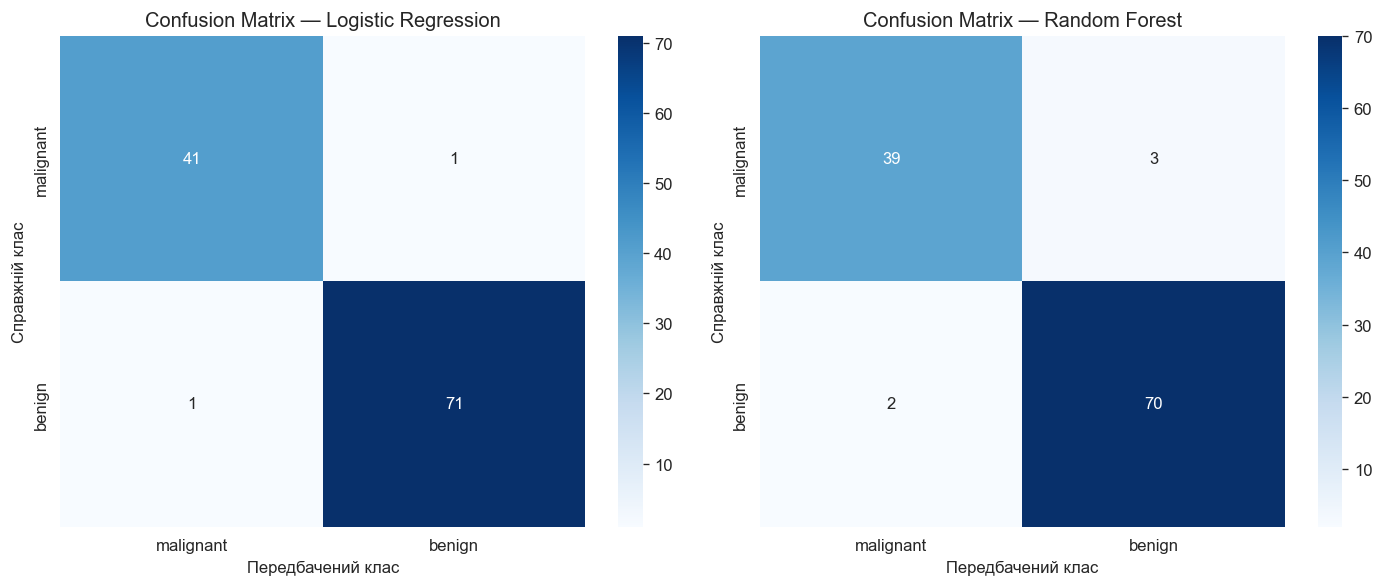

In [13]:
# Confusion Matrix — візуалізація для обох моделей
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models_data = [
    ("Logistic Regression", y_pred_lr_test, "confusion_matrix_lr.png"),
    ("Random Forest", y_pred_rf_test, "confusion_matrix_rf.png"),
]

for ax, (name, y_pred, filename) in zip(axes, models_data):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names,
                yticklabels=target_names, ax=ax)
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xlabel("Передбачений клас")
    ax.set_ylabel("Справжній клас")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/confusion_matrix_lr.png", bbox_inches="tight")
plt.show()

# Збереження окремих confusion matrix
for name, y_pred, filename in models_data:
    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names,
                yticklabels=target_names, ax=ax)
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xlabel("Передбачений клас")
    ax.set_ylabel("Справжній клас")
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{filename}", bbox_inches="tight")
    plt.close()

In [14]:
# Зведена таблиця метрик
metrics_data = []
for name, y_pred_train, y_pred_test in [
    ("Logistic Regression", y_pred_lr_train, y_pred_lr_test),
    ("Random Forest", y_pred_rf_train, y_pred_rf_test),
]:
    metrics_data.append({
        "Модель": name,
        "Accuracy (train)": accuracy_score(y_train, y_pred_train),
        "Accuracy (test)": accuracy_score(y_test, y_pred_test),
        "Precision": precision_score(y_test, y_pred_test, average="weighted"),
        "Recall": recall_score(y_test, y_pred_test, average="weighted"),
        "F1-score": f1_score(y_test, y_pred_test, average="weighted"),
    })

metrics_df = pd.DataFrame(metrics_data).set_index("Модель")
metrics_df = metrics_df.round(10)
print("Зведена таблиця метрик:")
metrics_df

Зведена таблиця метрик:


,Accuracy (train),Accuracy (test),Precision,Recall,F1-score
Модель,,,,,
Logistic Regression,0.989011,0.982456,0.982456,0.982456,0.982456
Random Forest,1.000000,0.956140,0.956073,0.956140,0.956027


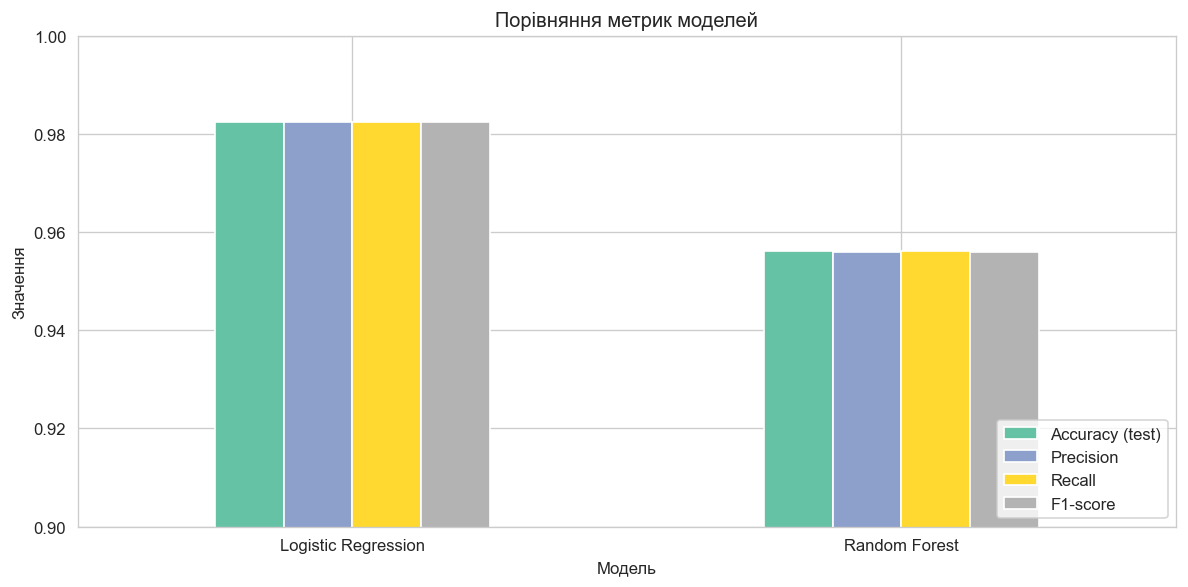

In [15]:
# Візуалізація порівняння метрик
fig, ax = plt.subplots(figsize=(10, 5))
metrics_plot = metrics_df[["Accuracy (test)", "Precision", "Recall", "F1-score"]]
metrics_plot.plot(kind="bar", ax=ax, rot=0, colormap="Set2")
ax.set_title("Порівняння метрик моделей")
ax.set_ylabel("Значення")
ax.set_ylim(0.9, 1.0)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/metrics_comparison.png", bbox_inches="tight")
plt.show()

# Аналіз результатів

In [16]:
# Перевірка overfitting: порівняння accuracy на train vs test
print("Перевірка перенавчання (overfitting):")
print(f"{'Модель':<25} {'Train Acc':>10} {'Test Acc':>10} {'Різниця':>10}")
print("-" * 55)
for name, y_pred_train, y_pred_test in [
    ("Logistic Regression", y_pred_lr_train, y_pred_lr_test),
    ("Random Forest", y_pred_rf_train, y_pred_rf_test),
]:
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    diff = train_acc - test_acc
    print(f"{name:<25} {train_acc:>10.4f} {test_acc:>10.4f} {diff:>10.4f}")

print("\n* Якщо різниця між train та test accuracy значна (>0.05),")
print("  це може свідчити про перенавчання моделі.")

Перевірка перенавчання (overfitting):
Модель                     Train Acc   Test Acc    Різниця
-------------------------------------------------------
Logistic Regression           0.9890     0.9825     0.0066
Random Forest                 1.0000     0.9561     0.0439

* Якщо різниця між train та test accuracy значна (>0.05),
  це може свідчити про перенавчання моделі.


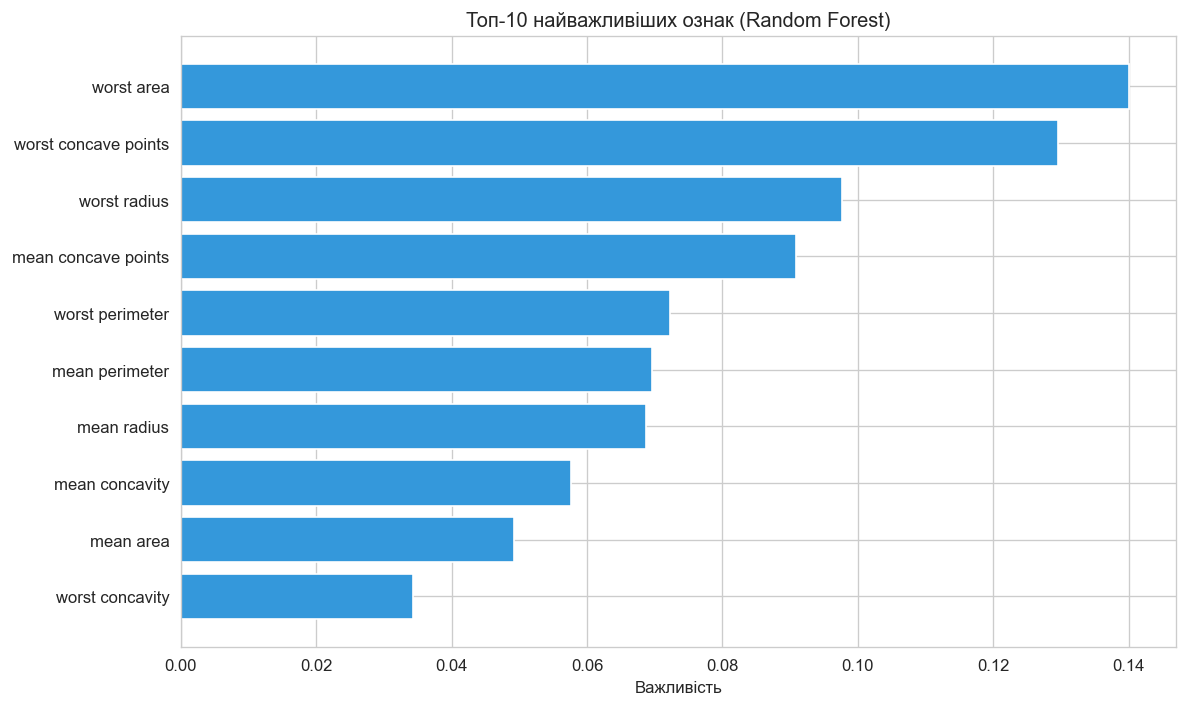


Топ-10 ознак:
  worst area: 0.1400
  worst concave points: 0.1295
  worst radius: 0.0977
  mean concave points: 0.0909
  worst perimeter: 0.0722
  mean perimeter: 0.0696
  mean radius: 0.0687
  mean concavity: 0.0576
  mean area: 0.0492
  worst concavity: 0.0343


In [17]:
# Найважливіші ознаки (Feature Importance) — Random Forest
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    "Ознака": data.feature_names,
    "Важливість": importances,
}).sort_values("Важливість", ascending=False)

# Топ-10 найважливіших ознак
top_n = 10
fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_importance_df.head(top_n)
ax.barh(top_features["Ознака"][::-1], top_features["Важливість"][::-1], color="#3498db")
ax.set_title(f"Топ-{top_n} найважливіших ознак (Random Forest)")
ax.set_xlabel("Важливість")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/feature_importance.png", bbox_inches="tight")
plt.show()

print(f"\nТоп-{top_n} ознак:")
for i, row in top_features.iterrows():
    print(f"  {row['Ознака']}: {row['Важливість']:.4f}")

# Додаткове завдання: крос-валідація та дослідження гіперпараметрів

In [18]:
# k-fold крос-валідація (k=5)
k = 5
print(f"Крос-валідація (k={k}):")
print("-" * 50)

for name, model in [
    ("Logistic Regression", LogisticRegression(random_state=RANDOM_STATE, max_iter=10000)),
    ("Random Forest", RandomForestClassifier(random_state=RANDOM_STATE)),
]:
    scores = cross_val_score(model, X_train_scaled, y_train, cv=k, scoring="accuracy")
    print(f"{name}:")
    print(f"  Scores: {scores.round(4)}")
    print(f"  Mean:   {scores.mean():.4f} (+/- {scores.std():.4f})")
    print()

Крос-валідація (k=5):
--------------------------------------------------
Logistic Regression:
  Scores: [0.967 0.978 0.967 1.    0.989]
  Mean:   0.9802 (+/- 0.0128)

Random Forest:
  Scores: [0.967  0.989  0.9231 0.9341 0.956 ]
  Mean:   0.9538 (+/- 0.0235)



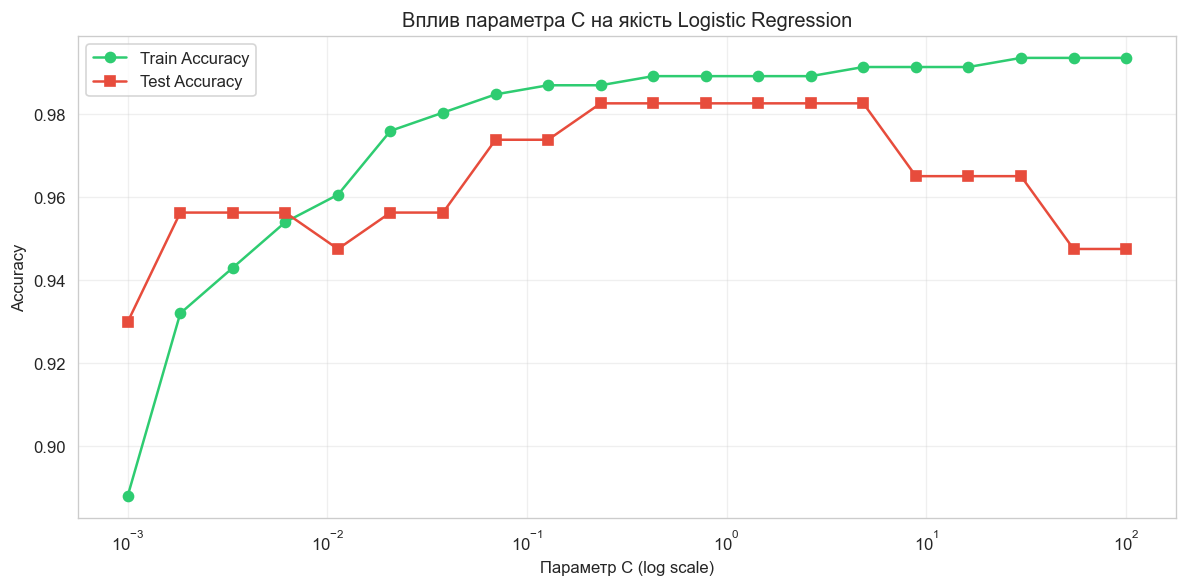

Оптимальне значення C: 0.2336
  Train Accuracy: 0.9868
  Test Accuracy:  0.9825


In [19]:
# Дослідження впливу гіперпараметра C на Logistic Regression
C_values = np.logspace(-3, 2, 20)  # від 0.001 до 100
train_scores = []
test_scores = []

for C in C_values:
    model = LogisticRegression(C=C, random_state=RANDOM_STATE, max_iter=10000)
    model.fit(X_train_scaled, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train_scaled)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test_scaled)))

# Графік залежності accuracy від C
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(C_values, train_scores, "o-", label="Train Accuracy", color="#2ecc71")
ax.plot(C_values, test_scores, "s-", label="Test Accuracy", color="#e74c3c")
ax.set_xscale("log")
ax.set_xlabel("Параметр C (log scale)")
ax.set_ylabel("Accuracy")
ax.set_title("Вплив параметра C на якість Logistic Regression")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/hyperparameter_c.png", bbox_inches="tight")
plt.show()

# Оптимальне значення C
best_idx = np.argmax(test_scores)
print(f"Оптимальне значення C: {C_values[best_idx]:.4f}")
print(f"  Train Accuracy: {train_scores[best_idx]:.4f}")
print(f"  Test Accuracy:  {test_scores[best_idx]:.4f}")